In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pl.Config.set_tbl_rows(15)

num_cores = multiprocessing.cpu_count()
print(num_cores)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


16


In [2]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
variant_class = 'intronic'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
"""conservation""","""verphylop""","""#440154""","""Vertebrate PhyloP""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1
"""splicing""","""pangolin_score""","""#20c997""","""Pangolin""",1
"""splicing""","""delta_score""","""#00A99D""","""Splice AI""",1


In [4]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/variant_classes/genebass1e6_genes_{variant_class.lower()}_variants_annotations.parquet")

cols = anno.collect_schema().names()
rename_map = {}
for c in cols:
    new = c.lower()
    if new.startswith('cadd_') and (not new.startswith('cadd_raw') and not new.startswith('cadd_phred')):
        new = new[len('cadd_'):]
    rename_map[c] = new

anno = anno.rename(rename_map)
anno.head().collect()

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,mmsp_donorintron_is_nan,dist2mutation_is_nan,freq100bp_is_nan,rare100bp_is_nan,sngl100bp_is_nan,freq1000bp_is_nan,rare1000bp_is_nan,sngl1000bp_is_nan,freq10000bp_is_nan,rare10000bp_is_nan,sngl10000bp_is_nan,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""chr14""",31130179,"""C""","""A""","""chr14:31130179:C:A""",64643901,"""ENSG00000092148""",0,0.0,0.561672,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0
"""chr14""",31130203,"""C""","""T""","""chr14:31130203:C:T""",64643910,"""ENSG00000092148""",0,0.0,1.444119,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0
"""chr14""",31130250,"""G""","""A""","""chr14:31130250:G:A""",64643923,"""ENSG00000092148""",0,0.0,0.886966,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0
"""chr14""",31130270,"""T""","""C""","""chr14:31130270:T:C""",64643934,"""ENSG00000092148""",0,0.0,0.36034,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0
"""chr14""",31130300,"""T""","""G""","""chr14:31130300:T:G""",64643944,"""ENSG00000092148""",0,0.0,0.8545,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


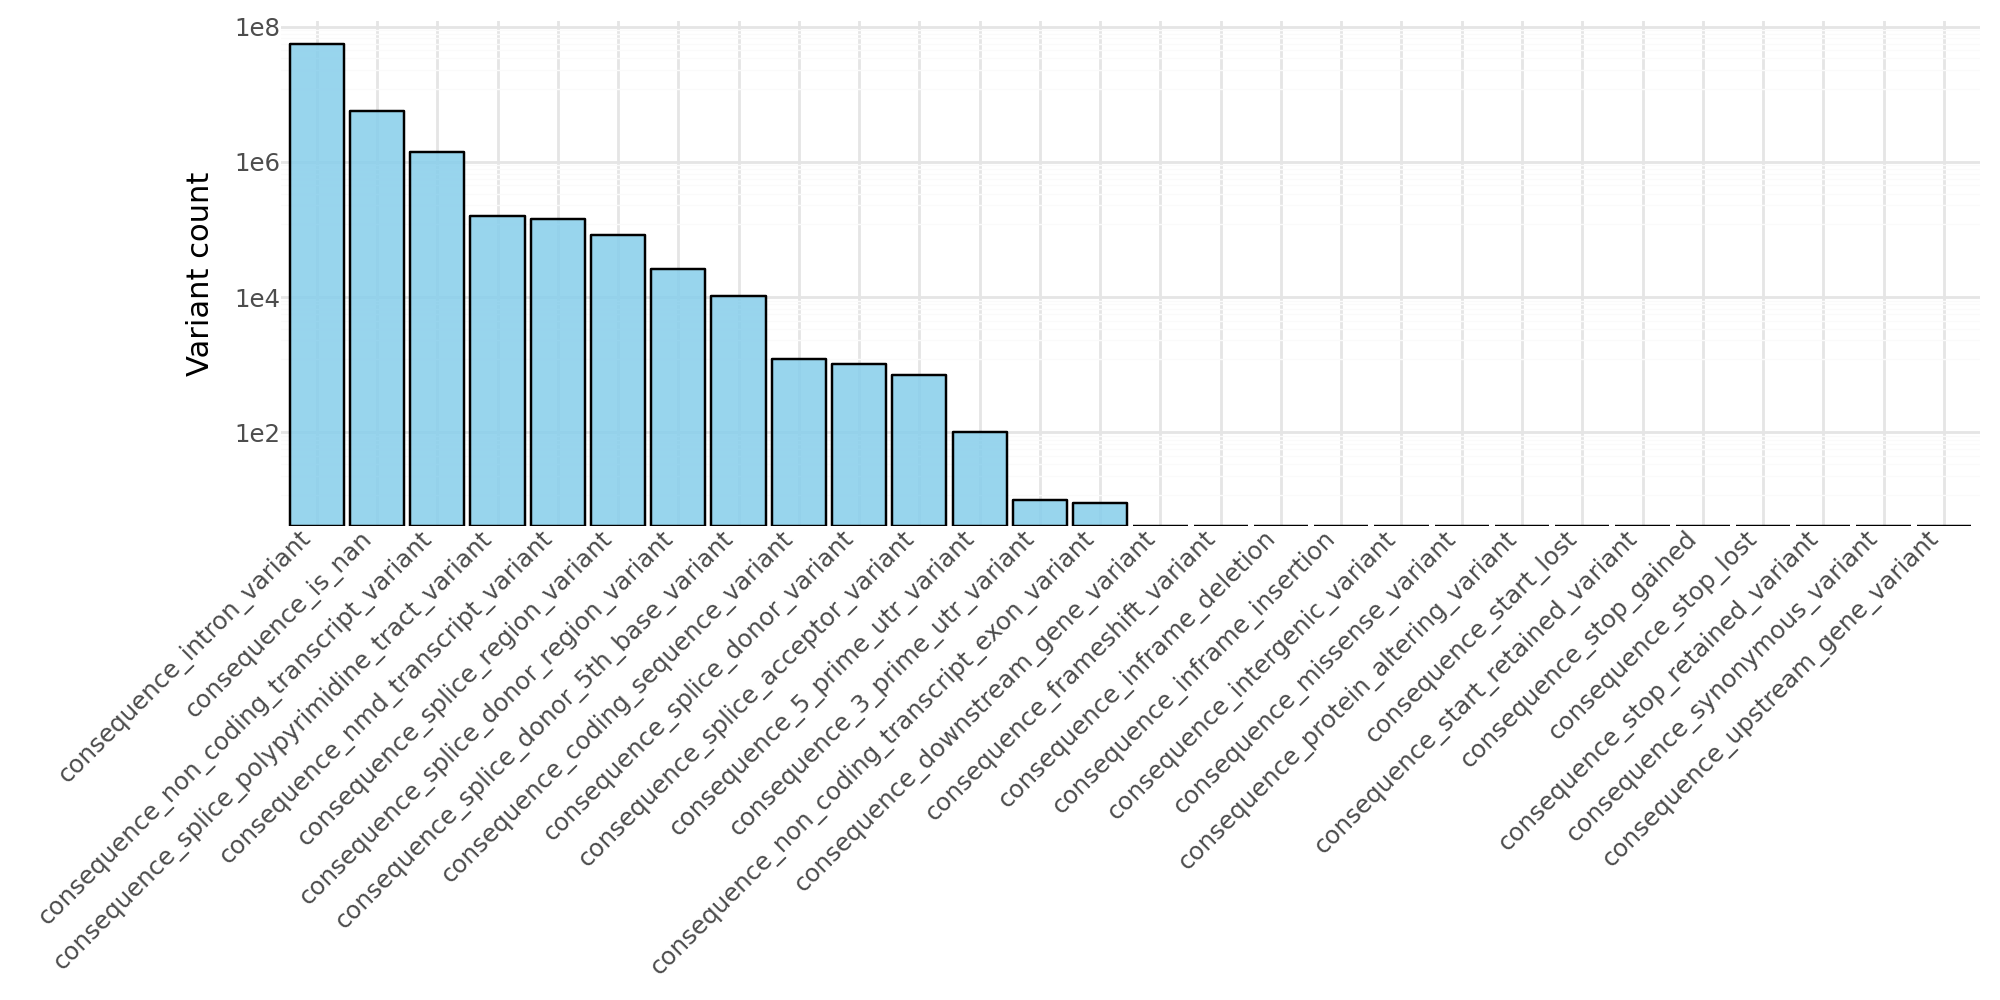

In [5]:
cons_annos = [c for c in anno.collect_schema().names() if c[:12] == 'consequence_']

# Plot counts of variant consequences
counts = (
    anno.select(cons_annos)
    .sum()
    .collect()
    .unpivot(variable_name='Consequence', value_name='Count')
    .sort('Count', descending=True)
    .to_pandas()
)

# preserve order for plotting
counts['Consequence'] = pd.Categorical(counts['Consequence'], categories=counts['Consequence'].tolist(), ordered=True)

(
    ggplot(counts, aes(x='Consequence', y='Count')) +
    geom_col(fill='skyblue', color='black', alpha=0.85) +
    theme_minimal() +
    labs(x='', y='Variant count') +
    scale_x_discrete(limits=counts['Consequence'].cat.categories.tolist()) +
    scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)